# Problem Set 1: Tensors and Automatic Differentiation

## 1a: Create tensors and perform the specified operations

### Set Up

In [ ]:
import torch
from torch import nn
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Compose, Grayscale
import random
import statistics
import matplotlib.pyplot as plt

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # Apple Silicon Metal Performance Shaders
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # GPU
else:
    DEVICE = torch.device("cpu") # CPU

### Create a tensor a containing the values [1.0, 2.0, 3.0, 4.0, 5.0]

In [2]:
a = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0], dtype =torch.float32).to(DEVICE)

### Create a 3×3 tensor B filled with ones

In [4]:
B = torch.ones(3, 3, dtype=torch.float32)

### Reshape a to a 5×1 column vector

In [11]:
a = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0], dtype =torch.float32).to(DEVICE)
a = torch.reshape(a, (5,1))
print(a.shape)

torch.Size([5, 1])


### Compute the element-wise square of a

In [12]:
a_square = torch.square(a)
print(a_square)

tensor([[ 1.],
        [ 4.],
        [ 9.],
        [16.],
        [25.]], device='mps:0')


### Compute the matrix product of B with itself

In [13]:
BB = torch.matmul(B, B)
print(BB)

tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])


## 1b: PyTorch’s automatic differentiation (univariate)

### Consider $f(x) = x^2 + 3x + 1$, compute $\frac{df}{dx}$ analytically, what is its value at $x=2$

Solution: $\frac{df}{dx} = 2x + 3$, at $x=2$, equals $7$

### Create a tensor x = torch.tensor([2.0], requires_grad=True) and compute y = x**2 + 3*x + 1

In [14]:
x = torch.tensor([2.0], requires_grad=True)
y = x**2 + 3*x + 1
print(y)

tensor([11.], grad_fn=<AddBackward0>)


### Call y.backward() to compute the gradient, then print x.grad

In [15]:
y.backward()
print(x.grad)

tensor([7.])


We can verify that PyTorch’s gradient matches analytical result

## 1c: PyTorch’s automatic differentiation (multivariate)

### Consider the function $𝑔(𝑥, 𝑦) = 𝑥^2𝑦 + 𝑦^3$, compute $\frac{dg}{dx}$ and $\frac{dg}{dy}$ analytically

- $\frac{dg}{dx} = 2xy$
- $\frac{dg}{dy} = x^2 + 3y^2$
- at (3,2), $\frac{dg}{dx} = 12$, $\frac{dg}{dy} = 21$

### Use PyTorch to compute both partial derivatives at (𝑥, 𝑦) = (1, 2)

In [17]:
x = torch.tensor([3.0], requires_grad=True)
y = torch.tensor([2.0], requires_grad=True)
g = ((x**2) * y) + (y**3)
g.backward()
print(x.grad)
print(y.grad)

tensor([12.])
tensor([21.])


## 2a: Visualize the data, then create a linear regression model y = Wx + b using nn.Linear, W and b are learnable parameters

### Set Up

In [68]:
# Generate synthetic data for linear regression
n_samples = 100
true_weight = 3.5
true_bias = 1.2
X = torch.randn(n_samples, 1)
y = true_weight * X + true_bias + 0.3 * torch.randn(n_samples, 1)

### Create a model

In [69]:
model = nn.Linear(in_features=1, out_features=1)

### Print the initial (random) weight and bias

In [71]:
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[-0.3675]], requires_grad=True)
Parameter containing:
tensor([0.0152], requires_grad=True)


### Make predictions on X and plot them alongside the true data

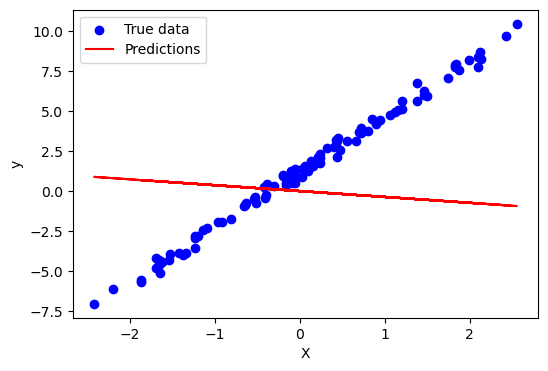

In [72]:
with torch.no_grad():
    predictions = model(X)

X_np = X.detach().numpy()
y_np = y.detach().numpy()
pred_np = predictions.detach().numpy()

plt.figure(figsize=(6, 4))
plt.scatter(X_np, y_np, label="True data", color="blue")
plt.plot(X_np, pred_np, label="Predictions", color="red")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 2b: Implement the training loop to fit the model. 

Epoch [10/100], Loss: 13.5092
Epoch [20/100], Loss: 7.8301
Epoch [30/100], Loss: 4.5569
Epoch [40/100], Loss: 2.6697
Epoch [50/100], Loss: 1.5809
Epoch [60/100], Loss: 0.9525
Epoch [70/100], Loss: 0.5894
Epoch [80/100], Loss: 0.3795
Epoch [90/100], Loss: 0.2581
Epoch [100/100], Loss: 0.1877


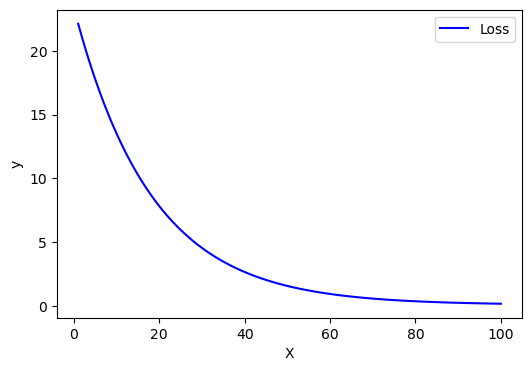

In [73]:
model = model.to(DEVICE) # Model and data must be on the same device
X_train = X.to(DEVICE).unsqueeze(1)
y_train = y.to(DEVICE)

criterion = nn.MSELoss() 
optimizer = optim.SGD(model.parameters(), lr=0.01)
n_epochs = 100

loss_list = list()

for epoch in range(n_epochs):
    # FORWARD PASS: compute predictions and loss.
    outputs = model(X_train)
    loss = criterion(outputs, y_train.unsqueeze(1))  # target shape (n, 1) to match outputs

    # BACKWARD PASS: compute gradients, then update parameters.
    optimizer.zero_grad()  # clear gradients before each backward (otw. they accumulate)
    loss.backward()        # fill gradients for all parameters with requires_grad=True
    optimizer.step()       # update parameters using those gradients

    loss_list.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

plt.figure(figsize=(6, 4))
plt.plot(range(1, n_epochs+1), loss_list, label="Loss", color="blue")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

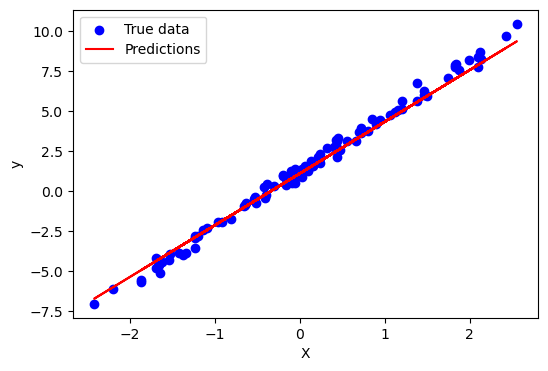

In [77]:
predictions = model(X_train)

X_np = X.detach().numpy()
y_np = y.detach().numpy()
pred_np = predictions.detach().cpu().squeeze(1).numpy()

plt.figure(figsize=(6, 4))
plt.scatter(X_np, y_np, label="True data", color="blue")
plt.plot(X_np, pred_np, label="Predictions", color="red")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 2c: After training

### Print the learned weight and bias

In [78]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'{name}: {param.detach().cpu().numpy()}')

weight: [[3.2405677]]
bias: [1.1104083]


### Compute the analytical OLS solution

In [88]:
ones = torch.ones((X.shape[0], 1), device=X.device, dtype=X.dtype)
X_aug = torch.cat([ones, X], dim=1)
X_t = X_aug.t()
X_t_X = torch.matmul(X_t, X_aug)
X_t_X_inv = torch.linalg.inv(X_t_X)
solution = torch.matmul(torch.matmul(X_t_X_inv, X_t), y)
solution

tensor([[1.2329],
        [3.4747]])

## 2d: Compare SGD with the Adam optimizer (optim.Adam). Retrain the model with both optimizers and plot their loss curves.

Epoch [10/100], Loss: 5.5775
Epoch [20/100], Loss: 1.8181
Epoch [30/100], Loss: 0.3345
Epoch [40/100], Loss: 0.0971
Epoch [50/100], Loss: 0.1374
Epoch [60/100], Loss: 0.1223
Epoch [70/100], Loss: 0.0958
Epoch [80/100], Loss: 0.0903
Epoch [90/100], Loss: 0.0910
Epoch [100/100], Loss: 0.0905


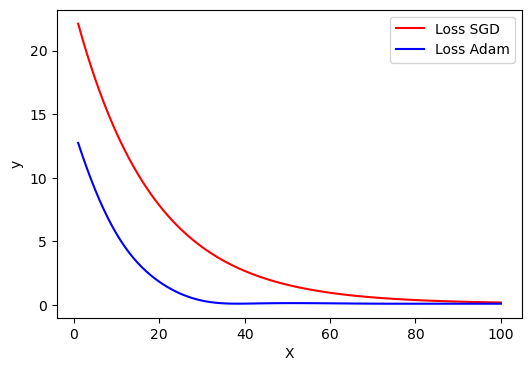

In [91]:
model2 = nn.Linear(in_features=1, out_features=1)
model2 = model2.to(DEVICE)

X_train = X.to(DEVICE).unsqueeze(1)
y_train = y.to(DEVICE)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model2.parameters(), lr=0.1)
n_epochs = 100

loss_list2 = list()

for epoch in range(n_epochs):
    # FORWARD PASS: compute predictions and loss.
    outputs = model2(X_train)
    loss = criterion(outputs, y_train.unsqueeze(1))  # target shape (n, 1) to match outputs

    # BACKWARD PASS: compute gradients, then update parameters.
    optimizer.zero_grad()  # clear gradients before each backward (otw. they accumulate)
    loss.backward()        # fill gradients for all parameters with requires_grad=True
    optimizer.step()       # update parameters using those gradients

    loss_list2.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

plt.figure(figsize=(6, 4))
plt.plot(range(1, n_epochs+1), loss_list, label="Loss SGD", color="red")
plt.plot(range(1, n_epochs+1), loss_list2, label="Loss Adam", color="blue")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 3a: build a multi-layer perceptron (MLP) to classify handwritten digits from the MNIST dataset

### Set Up

100.0%
100.0%
100.0%
100.0%


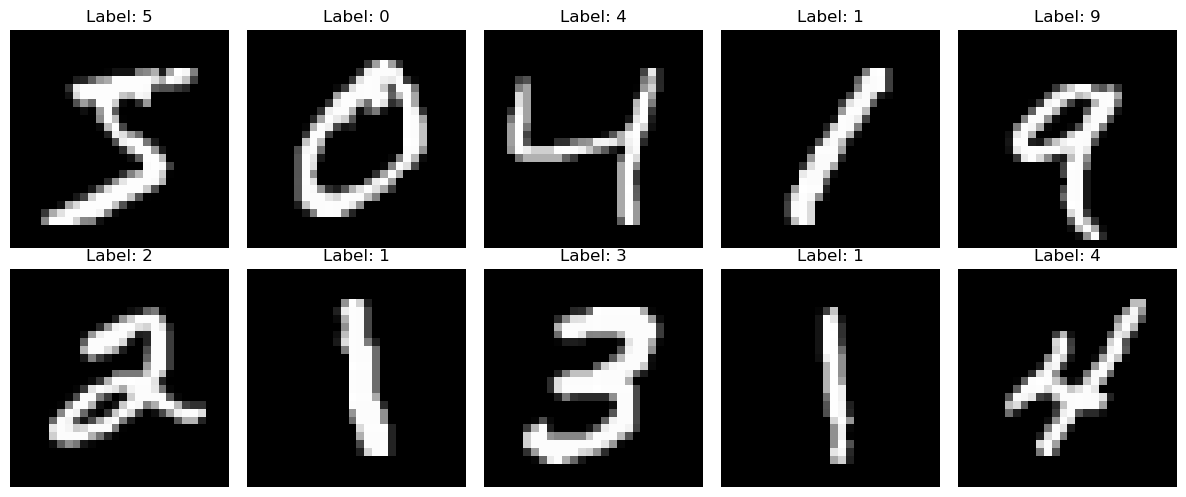

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [92]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST dataset
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

### Build an MLP with the following architecture using nn.Sequential
- Input: 784 features (28×28 flattened image)
- Hidden layer 1: 256 units, ReLU activation
- Hidden layer 2: 128 units, ReLU activation
- Output: 10 units (one per digit class)

In [100]:
MLP = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256), 
    nn.ReLU(), 
    nn.Linear(256, 128), 
    nn.ReLU(),
    nn.Linear(128, 10), 
    nn.Softmax(dim=1)
)
print(f"Model structure: {MLP}\n\n")

Model structure: Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
  (6): Softmax(dim=1)
)




In [101]:
def compute_accuracy(model, data_loader):
    model.eval() # Sets evaluation mode (disables dropout/batchnorm training behavior)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [102]:
MLP = MLP.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(MLP.parameters(), lr=0.001)
n_epochs = 5

average_loss_list = []
train_accuracy_list = []
test_accuracy_list = []

for epoch in range(n_epochs):

    MLP_loss_list = list()

    for batch, (X, y) in enumerate(train_loader):
        outputs = MLP(X.to(DEVICE))
        loss = criterion(outputs, y.to(DEVICE))
        optimizer.zero_grad()  # clear gradients before each backward (otw. they accumulate)
        loss.backward()        # fill gradients for all parameters with requires_grad=True
        optimizer.step()       # update parameters using those gradients

        MLP_loss_list.append(loss.item())
    
    average_loss = statistics.mean(MLP_loss_list)
    average_loss_list.append(average_loss)

    train_accuracy = compute_accuracy(MLP, train_loader)
    train_accuracy_list.append(train_accuracy)

    test_accuracy = compute_accuracy(MLP, test_loader)
    test_accuracy_list.append(test_accuracy)

    print(f'Epoch [{epoch + 1}/{n_epochs}], Average Loss: {average_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}', )

Epoch [1/5], Average Loss: 1.5785, Train Accuracy: 93.7183, Test Accuracy: 93.5900
Epoch [2/5], Average Loss: 1.5118, Train Accuracy: 95.7217, Test Accuracy: 95.4800
Epoch [3/5], Average Loss: 1.5007, Train Accuracy: 96.6500, Test Accuracy: 96.1000
Epoch [4/5], Average Loss: 1.4937, Train Accuracy: 96.4783, Test Accuracy: 95.9400
Epoch [5/5], Average Loss: 1.4900, Train Accuracy: 97.2033, Test Accuracy: 96.9000


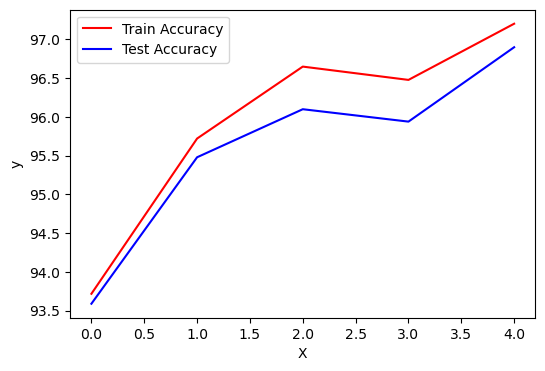

In [104]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(train_accuracy_list)), train_accuracy_list, label="Train Accuracy", color="red")
plt.plot(range(len(test_accuracy_list)), test_accuracy_list, label="Test Accuracy", color="blue")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

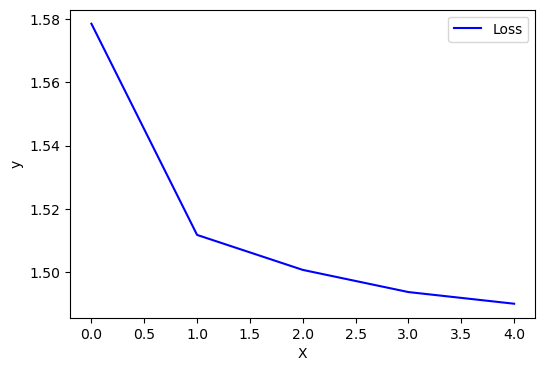

In [105]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(average_loss_list)), average_loss_list, label="Loss", color="blue")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### 3c: Evaluate and visualize

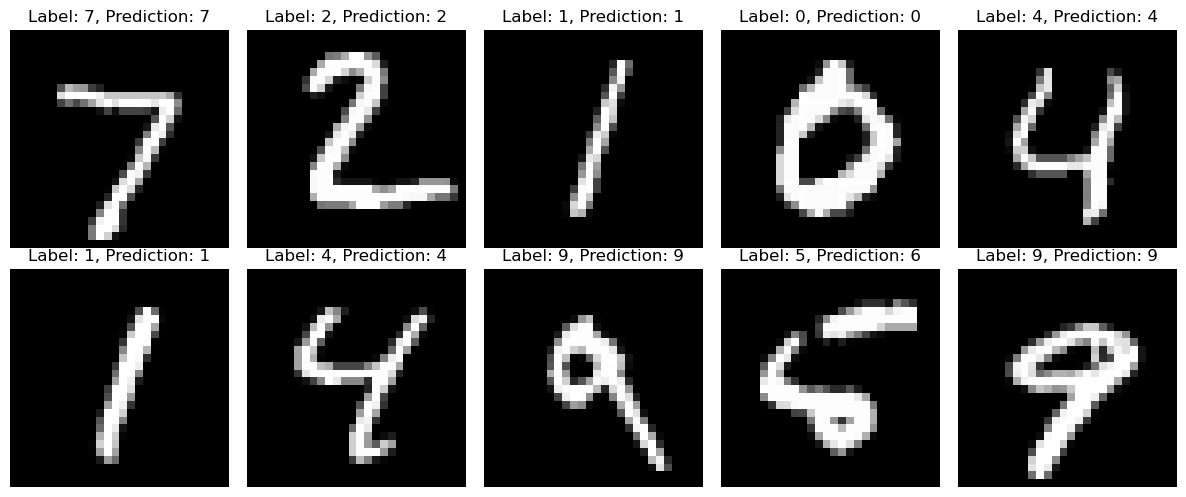

In [124]:
# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = test_dataset[i]
    output = MLP(img.to(DEVICE))
    max_idx = torch.argmax(output)
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}, Prediction: {max_idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()